In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import norm
import numpy as np

In [34]:
VARIABLE = "heat_index" # "edv", "temp", or "heat_index"

assert VARIABLE in ["edv", "temp", "heat_index"], f"invalid `VARIABLE` value: {VARIABLE}"

INPUT_FILE = f"../data/{VARIABLE}/regional_{VARIABLE}_data.csv"
OUTPUT_FILE = f"../data/{VARIABLE}/{VARIABLE}_seasonality.csv"
PLOT_OUTPUT_FILE = f"../plots/seasonality/{VARIABLE}_seasonality.png"
USE_LN = False

In [35]:
OMEGA = 1/365.25
PHI = 2*np.pi*OMEGA

def f(t, beta_0, beta_s, beta_c):
    if USE_LN:
        return np.exp(beta_0 + beta_s*np.sin(PHI*t) + beta_c*np.cos(PHI*t))
    else:
        return beta_0 + beta_s*np.sin(PHI*t) + beta_c*np.cos(PHI*t)

In [36]:
df = pd.read_csv(INPUT_FILE, index_col=0)
y_min = df.values.min()
y_max = df.values.max()
y_range = y_max - y_min
df.head()

,Region 1,Region 2,Region 3,Region 4,Region 5,Region 6,Region 7,Region 8,Region 9,Region 10
2017-01-01,3.468634,2.600462,6.462785,18.555471,2.294150,19.821060,5.362934,-1.580401,8.536677,-0.450826
2017-01-02,2.621293,2.998787,6.381939,22.955157,6.366844,20.068152,9.287636,-1.523893,6.637229,-2.211465
2017-01-03,4.424051,4.232353,7.189474,22.127452,5.490709,17.035688,4.638983,-4.426964,9.652311,-4.023998
2017-01-04,5.001802,4.582527,8.207389,16.406916,-2.870900,8.215786,-6.269261,-4.388166,10.175371,-4.466136
2017-01-05,0.210023,-1.988233,0.540235,12.380149,-9.614144,8.342710,-9.267852,-7.605504,8.181101,-5.307164


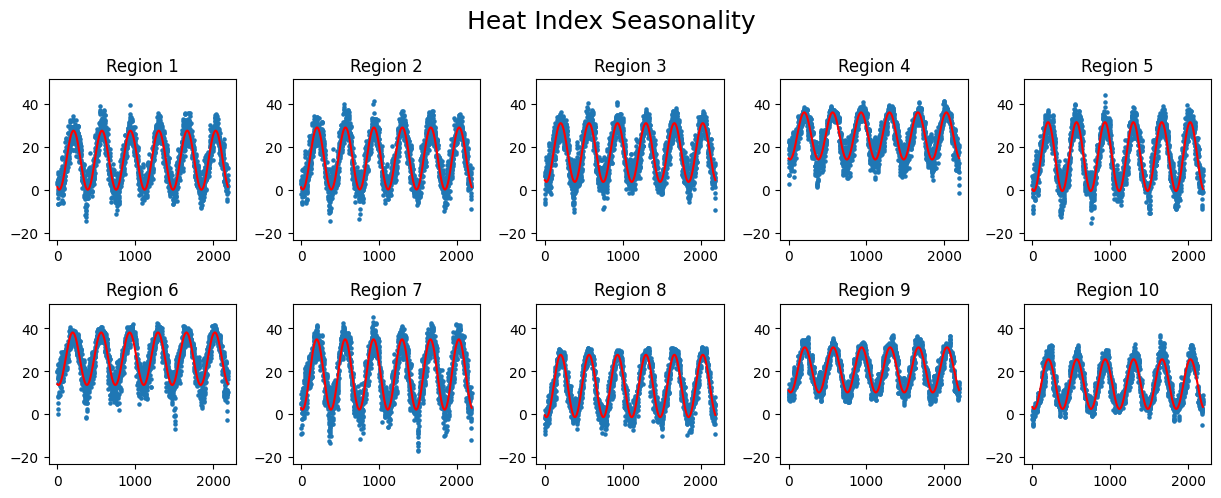

,region,beta_0,beta_s,beta_c,sigma_00,sigma_0s,sigma_0c,sigma_ss,sigma_sc,sigma_cc,psi,var_psi,peak_T,sigma_peak_T,peak_T_CI_lower,peak_T_CI_upper,gamma,var_gamma,theta
0,Region 1,13.739478,-5.687690,-12.527794,0.008489,-4.999515e-08,0.000004,0.016975,-1.000014e-07,0.016983,0.426180,0.000090,207.399419,0.550507,206.320445,208.478393,13.758468,0.016981,9.445535e+05
1,Region 2,14.529679,-5.355487,-13.425279,0.009239,-5.442256e-08,0.000004,0.018475,-1.088348e-07,0.018483,0.379567,0.000088,204.689738,0.546669,203.618286,205.761189,14.454043,0.018482,1.893699e+06
2,Region 3,17.309239,-4.557996,-12.909954,0.010001,-5.888980e-08,0.000005,0.019997,-1.178259e-07,0.020006,0.339399,0.000107,202.354707,0.600437,201.177871,203.531542,13.690954,0.020005,8.828885e+05
3,Region 4,25.044862,-3.300393,-10.474798,0.007199,-4.239328e-08,0.000003,0.014394,-8.479619e-08,0.014401,0.305233,0.000119,200.368605,0.635054,199.123921,201.613289,10.982440,0.014400,5.883191e+04
4,Region 5,15.416063,-5.183047,-15.192287,0.010042,-5.914232e-08,0.000005,0.020080,-1.182726e-07,0.020089,0.328781,0.000078,201.737461,0.513178,200.731650,202.743271,16.052089,0.020088,9.361243e+06
5,Region 6,25.886921,-3.021738,-11.860437,0.008990,-5.290994e-08,0.000004,0.017976,-1.059350e-07,0.017985,0.249467,0.000120,197.126869,0.636811,195.878742,198.374996,12.239316,0.017984,2.067604e+05
6,Region 7,18.533882,-4.896479,-15.636543,0.012541,-7.385420e-08,0.000006,0.025077,-1.477195e-07,0.025088,0.303471,0.000093,200.266168,0.561823,199.165014,201.367322,16.385267,0.025087,1.306264e+07
7,Region 8,13.188790,-5.007413,-13.642932,0.006019,-3.544263e-08,0.000003,0.012035,-7.090739e-08,0.012041,0.351768,0.000057,203.073754,0.438834,202.213655,203.933853,14.532852,0.012040,2.048979e+06
8,Region 9,20.676802,-4.431192,-9.534804,0.004551,-2.680563e-08,0.000002,0.009100,-5.358850e-08,0.009104,0.435043,0.000082,207.914623,0.527432,206.880876,208.948370,10.514178,0.009103,3.683407e+04
9,Region 10,14.052286,-4.389843,-10.716824,0.005431,-3.198478e-08,0.000002,0.010859,-6.396563e-08,0.010864,0.388773,0.000081,205.224913,0.523080,204.199694,206.250132,11.581064,0.010863,1.070513e+05


In [37]:
fig, axs = plt.subplots(2, 5, figsize=(15, 5))
plt.subplots_adjust(wspace=0.3, hspace=0.4)
data = []
for i, region in enumerate(df.columns):
    x = np.arange(len(df.index))
    y = df[region]
    betas, covs = curve_fit(f, x, y)

    beta_0, beta_s, beta_c = betas
    (sigma_00, sigma_0s, sigma_0c),\
    (_,        sigma_ss, sigma_sc),\
    (_,        _,        sigma_cc) = covs

    psi = np.arctan(beta_s/beta_c)
    var_psi = ((beta_c**2 * sigma_ss) + (beta_s**2 * sigma_cc) - (2 * sigma_sc * beta_s * beta_c)) / (beta_c**2 + beta_s**2)**2
    if beta_s > 0 and beta_c > 0:
        peak_T = psi / PHI
    elif beta_c < 0:
        peak_T = (psi + np.pi) / PHI
    else:
        peak_T = (psi + 2*np.pi) / PHI
    sigma_peak_T = np.sqrt(var_psi) / PHI
    z = norm.ppf(0.975)
    peak_T_CI = (peak_T - z*sigma_peak_T, peak_T + z*sigma_peak_T)
    gamma = np.sqrt(beta_c**2 + beta_s**2)
    var_gamma = ((beta_c**2 * sigma_cc) + (beta_s**2 * sigma_ss) - (2 * sigma_sc * beta_s * beta_c)) / (beta_c**2 + beta_s**2)
    theta = np.exp(gamma)
    M = z # M not specified in paper
    theta_CI = (np.exp(gamma - M*np.sqrt(var_gamma)), np.exp(gamma + M*np.sqrt(var_gamma)))

    data.append({
        "region": region,
        "beta_0": beta_0, "beta_s": beta_s, "beta_c": beta_c,
        "sigma_00": sigma_00, "sigma_0s": sigma_0s, "sigma_0c": sigma_0c, "sigma_ss": sigma_ss, "sigma_sc": sigma_sc, "sigma_cc": sigma_cc,
        "psi": psi, "var_psi": var_psi,
        "peak_T": peak_T, "sigma_peak_T": sigma_peak_T, "peak_T_CI_lower": peak_T_CI[0], "peak_T_CI_upper": peak_T_CI[1],
        "gamma": gamma, "var_gamma": var_gamma, "theta": theta,
        # "theta_CI_lower": theta_CI[0], "theta_CI_upper": theta_CI[1]
    })

    ax = axs[i//5,i%5]
    ax.scatter(x, y, s = 5)
    ax.plot(x, f(x, *betas), color = "red")
    ax.set_title(region)
    ax.set_ylim(y_min - y_range*0.1, y_max + y_range*0.1)

if VARIABLE == "edv":
    suptitle = "EDV"
elif VARIABLE == "temp":
    suptitle = "Temperature"
elif VARIABLE == "heat_index":
    suptitle = "Heat Index"
plt.suptitle(f"{suptitle} Seasonality", fontsize = 18, y = 1.02)

plt.savefig(PLOT_OUTPUT_FILE, dpi = 500, bbox_inches = "tight")
plt.show()
df_models = pd.DataFrame(data)
df_models

In [38]:
df_models.to_csv(OUTPUT_FILE, index = False)